:::{admonition} Run this notebook yourself!
:class: important

Download the executed notebook: **{nb-download}`how_to_penalty.ipynb`**!

Run it in your browser: **{binder}`how_to_penalty.ipynb`**!

:::

(how-to-penalty)=
# How to use custom penalty functions

Plenoptic's {class}`~plenoptic.Metamer` and {class}`~plenoptic.MADCompetition` objects allow users to specify a `penalty_function` at initialization. This penalty function is multiplied by `penalty_lambda` (also set at initialization) and added to the objective function of the object.

The default penalty function is {func}`~plenoptic.regularize.penalize_range`, which places a quadratic penalty on any pixel values outside of the range $[0, 1]$. In this notebook, we'll show how to change this penalty to use a different range of allowed values, and in so doing, talk about some general principles for using custom penalty functions.

In [1]:
import matplotlib.pyplot as plt
import torch

import plenoptic as po

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72
# Animation-related settings
plt.rcParams["animation.html"] = "html5"
# use single-threaded ffmpeg for animation writer
plt.rcParams["animation.writer"] = "ffmpeg"
plt.rcParams["animation.ffmpeg_args"] = ["-threads", "1"]

MAX_ITER = 4000

## Prepare model and image for synthesis

In this notebook, we'll use a simple {class}`~plenoptic.models.Gaussian` model. This model just convolves a Gaussian kernel across the entire image. It is thus a low-pass model, only caring about low frequencies and disregarding high ones.

First, let's see what metamer synthesis with the default penalty function looks like:

  0%|          | 0/4000 [00:00<?, ?it/s]

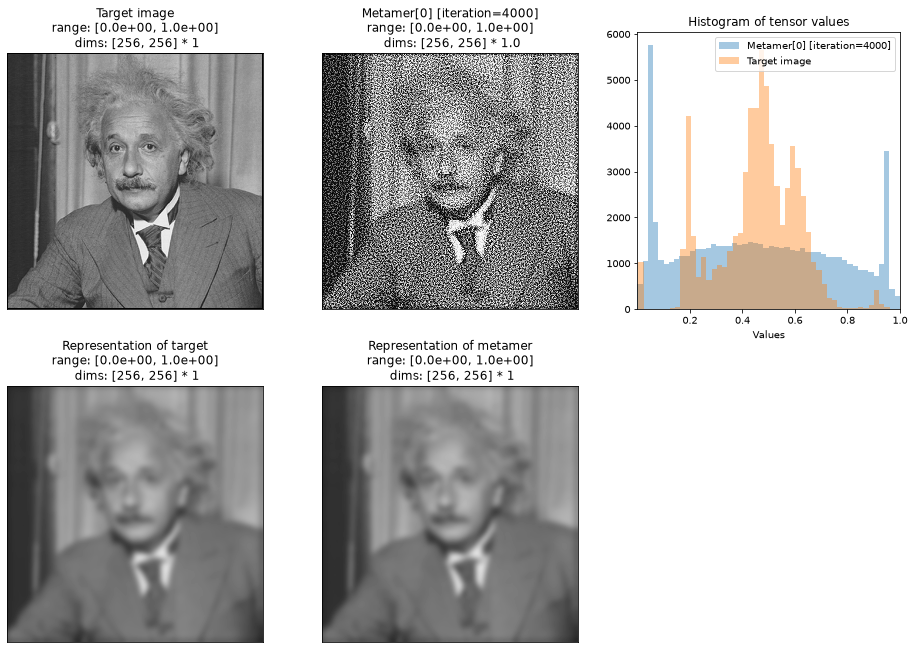

In [2]:
model = po.models.Gaussian(30, cache_filt=True).eval()
po.remove_grad(model)
model.to(DEVICE).to(torch.float64)
img = po.data.einstein().to(DEVICE).to(torch.float64)
met = po.Metamer(img, model)
met.synthesize(MAX_ITER, stop_criterion=1e-16)


def create_metamer_figure(met):
    fig, axes = plt.subplots(2, 3, figsize=(16, 11))
    axes = axes.flatten()
    included_plots = ["synthesis_imshow", "synthesis_histogram"]
    axes_idx = {k: i + 1 for i, k in enumerate(included_plots)}
    po.plot.synthesis_status(
        met,
        fig=fig,
        included_plots=included_plots,
        axes_idx=axes_idx,
        synthesis_imshow_kwargs={"vrange": (0, 1)},
    )
    image_axes = [axes[0], axes[3], axes[4]]
    imgs = [met.image, met.model(met.image), met.model(met.metamer)]
    titles = ["Target image", "Representation of target", "Representation of metamer"]
    for ax, im, t in zip(image_axes, imgs, titles):
        po.plot.imshow(im, ax=ax, title=t, zoom=1, vrange=(0, 1))
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
    axes[-1].set_visible(False)


create_metamer_figure(met)

In the above figure, the top row shows: the target image, the metamer, and a histogram of pixel values in those two images. The bottom rows shows the model representation of the top two rows. We can see that the two representations on the bottom match and thus the two images on the top are metamers.

By looking at the histogram (and the "range" section in the title of the images on the top row), we can see that the pixel values in our metamer vary between 0 and 1 and, since it was initialized with a patch of uniformly-distributed noise, those pixels are widely distributed between those values.

## Construct the custom penalty

All penalty functions in plenoptic must be callables that take the synthesized image as input and return some scalar penalty. We can write a custom penalty that makes use of the {func}`~plenoptic.regularize.penalize_range` function to penalize pixel values that fall outside some narrower range instead:

In [3]:
# Create custom_penalty function, that penalizes pixels outside of [0.1, 0.9] range
def custom_penalty(image):
    penalty = po.regularize.penalize_range(image, allowed_range=(0.1, 0.9))
    return penalty

In the following, we can see that our `custom_penalty` accepts a single tensor and returns a scalar, quadratic penalty on any values it contains outside of 0.1 to 0.9:

In [4]:
print(f"All twos -- high penalty: {custom_penalty(2 * torch.ones(10))}")
print(f"All 0.5 -- no penalty: {custom_penalty(0.5 * torch.ones(10))}")
print(f"Random between 0 and 1 -- medium penalty: {custom_penalty(torch.rand(10))}")

All twos -- high penalty: 12.100000381469727
All 0.5 -- no penalty: 0.0
Random between 0 and 1 -- medium penalty: 0.006105249747633934


Now we can pass this `custom_penalty` to the {class}`~plenoptic.Metamer` class at initialization and call the `synthesize` method in the same manner as before:

  0%|          | 0/4000 [00:00<?, ?it/s]

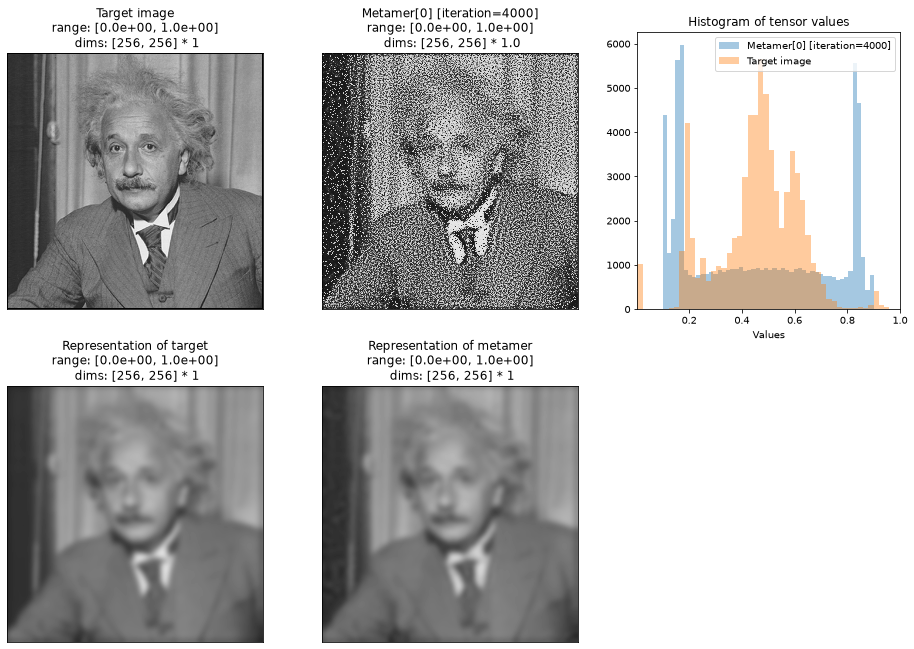

In [5]:
met = po.Metamer(img, model, penalty_function=custom_penalty)
met.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(met)

The figure above has the same structure as earlier, and we can see that the new metamer's pixel values all fall within this narrower range of $[0.1, 0.9]$. By looking at the second row, we can see that this image is still a metamer: the representation still looks identical to that of the target image.

## Best practices

The example shown above is relatively simple. However, for optimization to behave well, it is important that:
1. penalties have some minimum value (i.e., they cannot go to negative infinity).
2. this minimum value corresponds to the desired property (e.g., all pixels lie within the desired range).

Furthermore, it is generally convenient to have this minimum value be zero.

If the conditions above are violated, then the penalty can overwhelm the loss in the objective function, preventing a metamer (or MAD image) from being found.

To see why, let's say that we wanted to encourage all pixel values to lie *outside* the range $[0.4, 0.6]$. That is, we want to maximize the value from `po.regularize.penalize_range(image, allowed_range=(0.4, 0.6))`. The standard way to maximize a function in optimization frameworks is to minimize its negative value, so we can return the negative of the output from {func}`~plenoptic.regularize.penalize_range` instead:

In [6]:
def custom_penalty(image):
    penalty = po.regularize.penalize_range(image, allowed_range=(0.4, 0.6))
    return -penalty


print(f"All ones -- very negative penalty: {custom_penalty(torch.ones(10))}")
print(f"All 0.5 -- zero penalty: {custom_penalty(0.5 * torch.ones(10))}")
rand_penalty = custom_penalty(torch.rand(10))
print(f"Random between 0 and 1 -- intermediate penalty: {rand_penalty}")

All ones -- very negative penalty: -1.5999997854232788
All 0.5 -- zero penalty: -0.0
Random between 0 and 1 -- intermediate penalty: -0.38070064783096313


We are trying to minimize the value of `custom_penalty`. Thus, a large negative number if better than 0 (or any positive number). So of our three example inputs above, our penalty prefers the first. Let's see what this looks like with metamer synthesis:

  0%|          | 0/4000 [00:00<?, ?it/s]

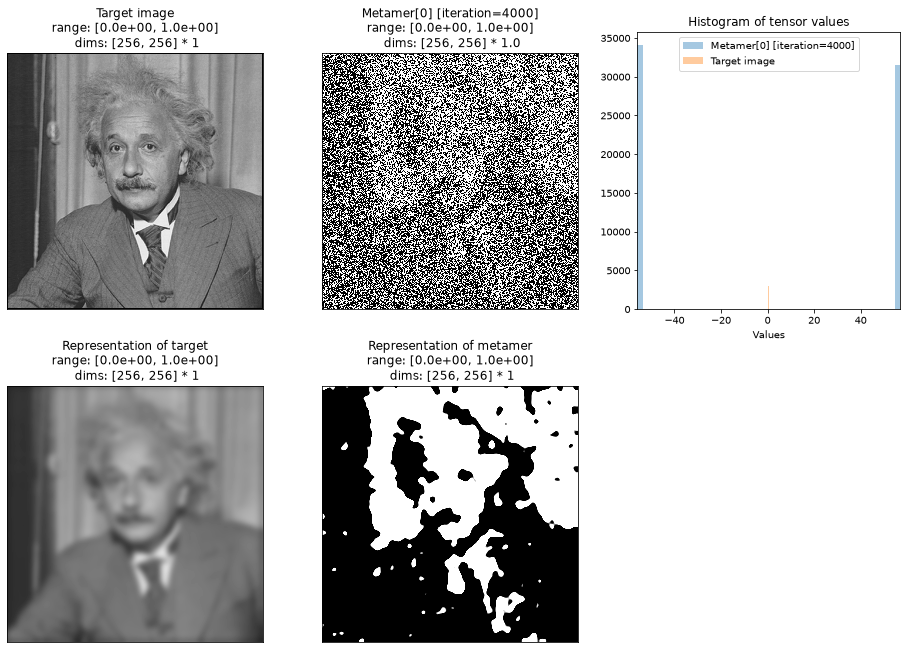

In [7]:
met = po.Metamer(img, model, penalty_function=custom_penalty)
met.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(met)

Oh no! Our model representations do not look like identical here.

To see why this is, let's use {func}`plenoptic.plot.synthesis_loss` to plot our metamer loss alongside our penalty value:

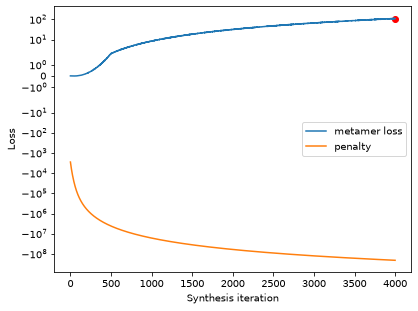

In [8]:
ax = po.plot.synthesis_loss(met, plot_penalties=True)
# convert this to symlog scale, so we can see negative values.
ax["loss"].set_yscale("symlog")

The penalty value is a large negative value and still going lower, whereas our loss has actually increased. Since our optimization problem is minimizing the weighted sum of these two numbers, and loss is bounded below by 0, the penalty has become much more important to the optimization problem, and it can effectively ignore the metamer loss.

In situations like this, the solution is to apply some function to the penalty so that its range is remapped from $(-\infty, 0]$ to $[0, \infty)$ (or $[0, x]$, for some finite $x$). Fortunately, the [exponential function](https://en.wikipedia.org/wiki/Exponential_function) will do this for us, remapping $(-\infty, 0]$ to $[0, 1]$:

In [9]:
def custom_penalty(image):
    penalty = po.regularize.penalize_range(image, allowed_range=(0.4, 0.6))
    return torch.exp(-penalty)

There's one addition subtlety here: if `penalty` in our function definition above gets too large, `torch.exp` becomes effectively zero and so the penalty has no effect:

In [10]:
penalty = po.regularize.penalize_range(torch.rand_like(img), allowed_range=(0.4, 0.6))
print(penalty.item())
print(torch.exp(-penalty).item())

2802.6404914414743
0.0


To avoid this, let's approximately rescale the input to `torch.exp` so that it never gets too large:

In [11]:
def custom_penalty(image):
    penalty = po.regularize.penalize_range(image, allowed_range=(0.4, 0.6))
    return torch.exp(-penalty / 1000)

With this modification, our custom penalty returns more reasonable values for the types of inputs it is likely to see:

In [12]:
print(custom_penalty(img).item())
print(custom_penalty(torch.rand_like(img)).item())

0.5172017687004513
0.062252712935930016


One final modification: when synthesizing images, it is generally desirable for all pixel values to lie within $[0, 1]$, so they can be displayed (which is why this is plenoptic's default behavior). To ensure that, let's modify our penalty one last time, summing together the two penalties before returning them.

In [13]:
def custom_penalty(image):
    outside_penalty = po.regularize.penalize_range(image, allowed_range=(0.4, 0.6))
    inside_penalty = po.regularize.penalize_range(image, allowed_range=(0, 1))
    return torch.exp(-outside_penalty / 1000) + inside_penalty

Now we can see that we get a zero value when the input satisfies both of our constraints above (that is, all pixel values lie within either $[0, 0.4]$ or $[0.6, 1]$) and gradually increases otherwise:

In [14]:
print(f"All ones -- low penalty: {custom_penalty(torch.ones_like(img))}")
rand_penalty = custom_penalty(torch.rand_like(img))
print(f"Randomly distributed between 0 and 1 -- middle penalty: {rand_penalty}")
print(f"All 0.5 -- high penalty: {custom_penalty(0.5 * torch.ones_like(img))}")
high_penalty = custom_penalty(1.5 * torch.ones_like(img))
print(f"All outside of 0 to 1 -- very high penalty: {high_penalty}")

All ones -- low penalty: 2.7931373575515134e-05
Randomly distributed between 0 and 1 -- middle penalty: 0.06248002602307129
All 0.5 -- high penalty: 1.0
All outside of 0 to 1 -- very high penalty: 16384.0


Now let's use the function for metamer synthesis:

  0%|          | 0/4000 [00:00<?, ?it/s]

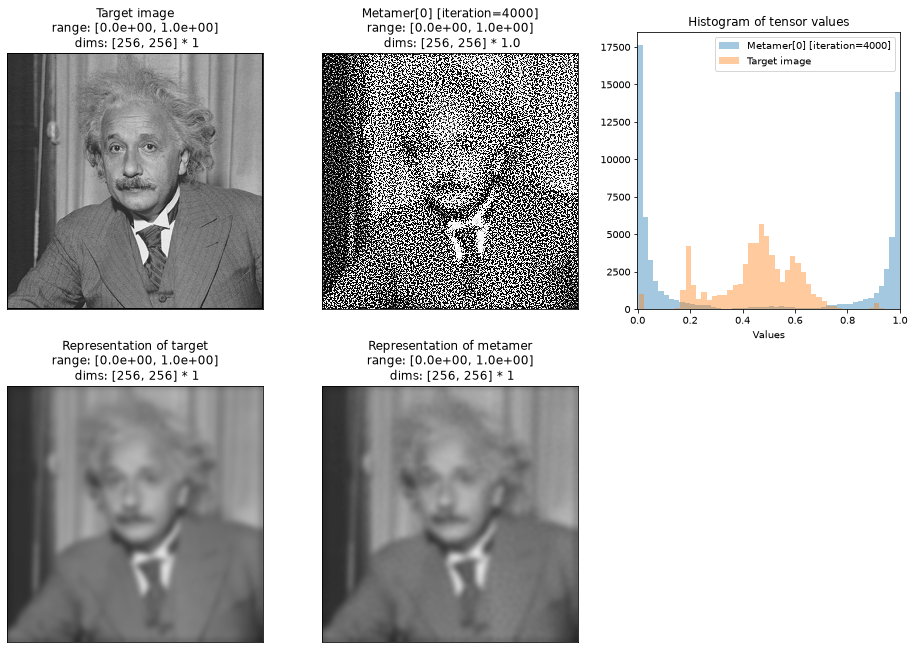

In [15]:
met = po.Metamer(img, model, penalty_function=custom_penalty)
met.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(met)

And now we can see that the model metamer pixel values mostly lie outside the range $[0.4, 0.6]$ and within $[0, 1]$.

However, if you look at the metamer representation image on the second row, you can see that it is not identical to the target representation just next to it (there are faint circles scattered across the image) -- that is, we've failed to find a metamer. We'll address that in the next section.

## How to choose lambda

In the previous example, we synthesized an image that satisfied the penalty function, but we gave up some of the metamer quality. That's bad, and results from the penalty playing too large of a role in the objective function.

In order to increase the relative importance of the metamer loss (over the penalty) in the objective function, we can use the {attr}`~plenoptic.Metamer.penalty_lambda` argument at initialization. This argument operates similarly to {attr}`~plenoptic.MADCompetition.metric_tradeoff_lambda` from {class}`~plenoptic.MADCompetition`, and allows us to control the balance of these components in the objective function.

This value defaults to 0.1, which you can see by looking at the docstring. Let's try decreasing it:

  0%|          | 0/4000 [00:00<?, ?it/s]

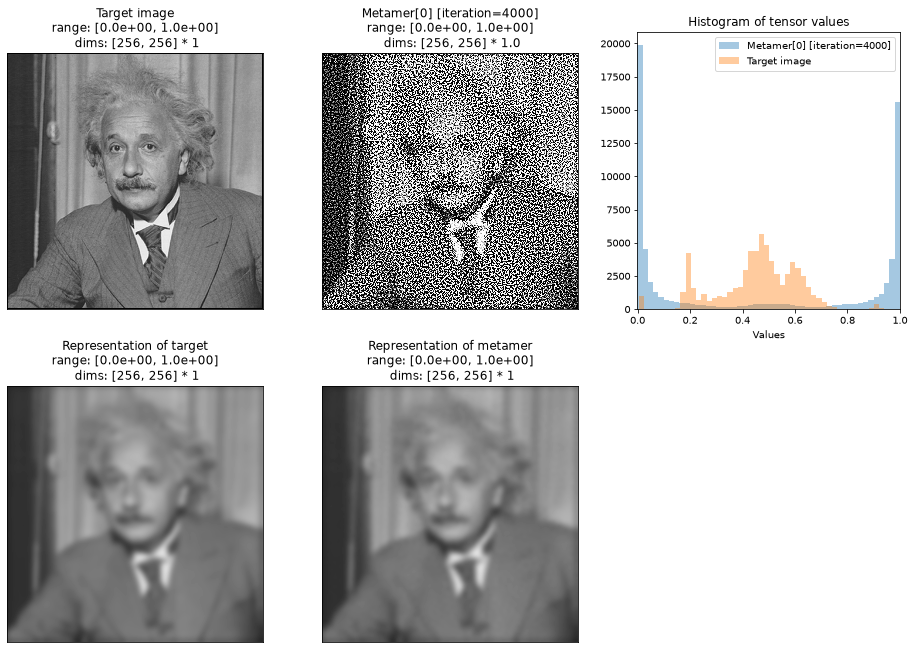

In [16]:
met = po.Metamer(img, model, penalty_function=custom_penalty, penalty_lambda=0.025)
met.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(met)

In the above plots, we can see that the metamer is of good quality (the two bottom images match), and that we have mostly managed to satisfy the constraints from our penalty (most pixel values lie outside the range $[0.4, 0.6]$ and within $[0, 1]$.)

If we continued to decrease `penalty_lambda`, eventually we'd reach a point where the penalty was having no effect at all:

  0%|          | 0/4000 [00:00<?, ?it/s]

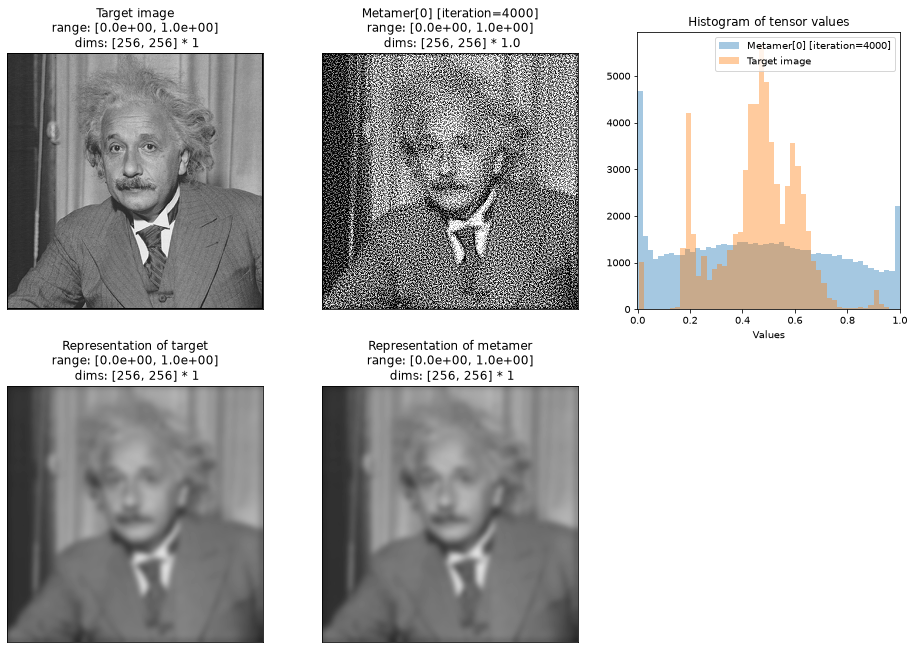

In [17]:
met_small = po.Metamer(img, model, penalty_function=custom_penalty, penalty_lambda=1e-6)
met_small.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(met_small)

While we have a good metamer, we can see that many pixel values in our metamer lie between 0.4 and 0.6.

Conversely, for a very large lambda, the objective function will focus exclusively on minimizing the penalty, ignoring the metamer loss entirely:

  0%|          | 0/4000 [00:00<?, ?it/s]

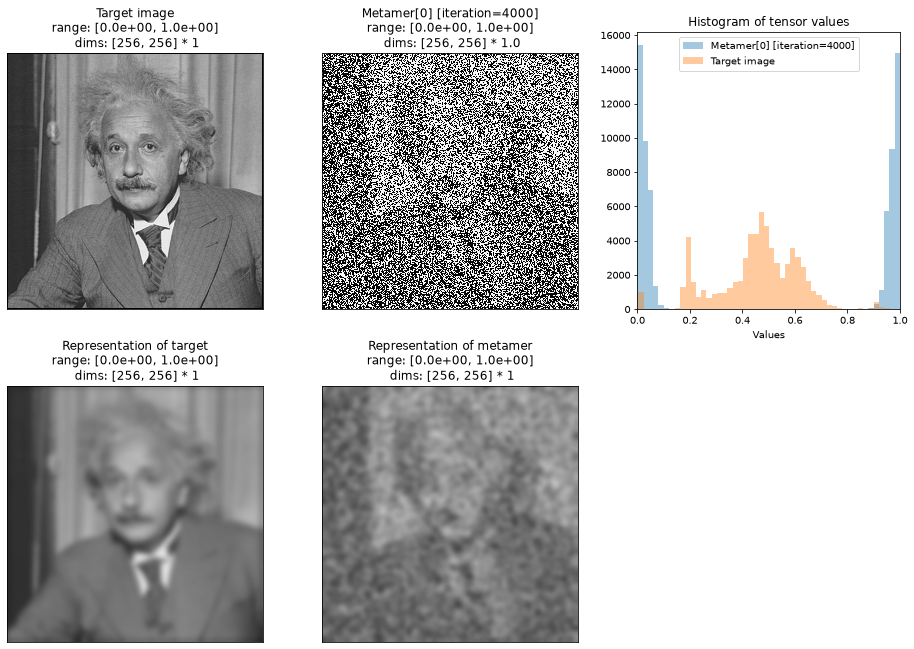

In [18]:
met_large = po.Metamer(img, model, penalty_function=custom_penalty, penalty_lambda=1e6)
met_large.synthesize(MAX_ITER, stop_criterion=1e-16)

create_metamer_figure(met_large)

While we have satisfied our constraint (all pixel values lie within $[0, 0.4]$ or $[0.6, 1]$), we have not successfully found a model metamer.

In all cases, the actual penalty values start at approximately the same value. Because of their relative importance in the objective function, their final value will vary: the larger lambda is, the lower the penalty will become, but at the potential cost of the loss remaining high.

Text(0.5, 1.0, 'Lambda too large')

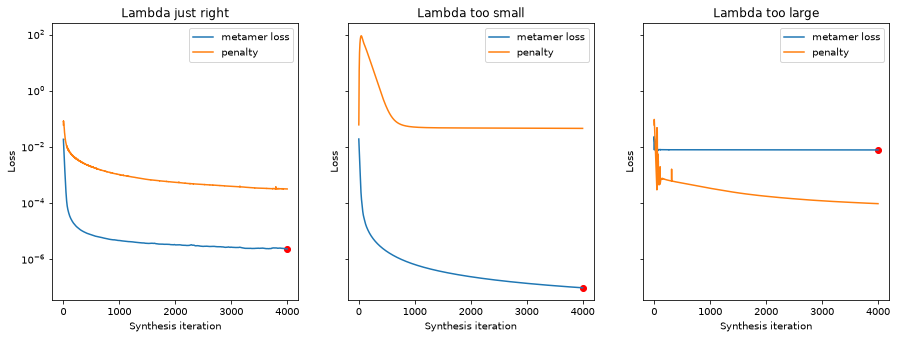

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
po.plot.synthesis_loss(met, plot_penalties=True, ax=axes[0])
axes[0].set_title("Lambda just right")
po.plot.synthesis_loss(met_small, plot_penalties=True, ax=axes[1])
axes[1].set_title("Lambda too small")
po.plot.synthesis_loss(met_large, plot_penalties=True, ax=axes[2])
axes[2].set_title("Lambda too large")

## Concluding thoughts

When trying out a new penalty function, you are encouraged to first ensure it complies to best practices, and then try out different values for `penalty_lambda` to find which one allows you to minimize both the penalty *and* the metamer (or MAD Competition) loss.